# Verifying the Chromatix Model

Finally, through the obligate use of transfer_propagate() instead of a curried propagator, we can verify the Chromatix multislice model multislice_thick_sample().

Now, to just make it jit-able (for jax autograd). 

## Imports and Params

(collapsable cells)

In [18]:
from time import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from src.spectral_xpci.xscatter import get_delta_beta_mix, get_wavelen
from chromatix.ops import init_plane_resample
import chromatix.functional as cx

### for my ALT versions:
from typing import Optional, Tuple, Union
from chex import assert_equal_shape, assert_rank
from jax import Array

from chromatix.field import crop, pad
from chromatix.utils.fft import fft, ifft
from chromatix.field import ScalarField, VectorField
from chromatix.utils import _broadcast_2d_to_spatial, center_pad
from chromatix.functional.polarizers import polarizer
from chromatix.functional.propagation import (
    compute_asm_propagator,
    compute_exact_propagator,
    exact_propagate,
    kernel_propagate,
)
### end ALT versions


class Material:
    def __init__(self, name, matcomp, density):
        self.name = name
        self.matcomp = matcomp
        self.density = density
    def delta_beta(self, energy):
        delta, beta = get_delta_beta_mix(self.matcomp, np.atleast_1d(energy), self.density)
        return delta.squeeze(), beta.squeeze()

pmma = Material('PMMA', 'H(8.06)C(59.98)O(31.96)', 1.19)
nylon = Material('nylon', 'H(9.7980)C(63.6853)N(12.3779)O(14.1388)', 1.15)



In [19]:
# Original (no comments)
# the annotated version is in comparing-two-multislice-functions.ipynb if you want a refresher

def make_fiber_phantom(N, Nz, dx, fiber_width, energy, 
                       fiber_material=nylon, background_material=pmma, height_fraction=0.8):
    fov = N*dx
    fiber_height = height_fraction*fov
    coords = np.abs(np.linspace(-fov/2, fov/2, N))
    X, Y = np.meshgrid(coords, coords)

    obj = np.zeros([Nz, N, N], dtype=np.uint8)
    # flag: why aren't thickness nor dz involved?
    for z in range(Nz):
        mask = np.where((X <= fiber_width/2) & (Y <= fiber_height/2))  
        obj[z][mask] = 1

    matdict = {0: background_material, 1: fiber_material}
    obj_delta = jnp.zeros(obj.shape)
    obj_beta = jnp.zeros(obj.shape)
    for mat_id in matdict:
        d, b = matdict[mat_id].delta_beta(energy)
        obj_delta = obj_delta.at[obj == mat_id].set(d)
        obj_beta = obj_beta.at[obj == mat_id].set(b)

    return obj_delta, obj_beta

In [20]:
####################################################################################
### Parameters #####################################################################
####################################################################################


energy = 20        # beam energy [keV]
propdist = 30e-2 

# Phantom:
N = 128              # num pixels in x-y plane (128/1024)
dx = 1e-6            # phantom resolution (dx = 1e-6/0.625e-6)
fov = N*dx           # field-of-view in the transverse plane (x-y)
fiber_width = 20e-6
Nz = 10              # num pixels along z axis
thickness = 5e-2     # thickness along propagation axis (z)
dz = thickness/Nz
phantom_shape = jnp.array([Nz, N, N])

# Detector:
det_shape = (128, 128)   
det_dx = fov / det_shape[0]  

# Misc:
N_pad = 100
n_medium = 1
n_avg = 1
key=jax.random.PRNGKey(3)

####################################################################################
####################################################################################



## Manual ALT function

maybe jit-able, maybe not. a standard for reference.

this cluster of cells is redundant with the last two cells of comparing-two-multislice-functions.ipynb.

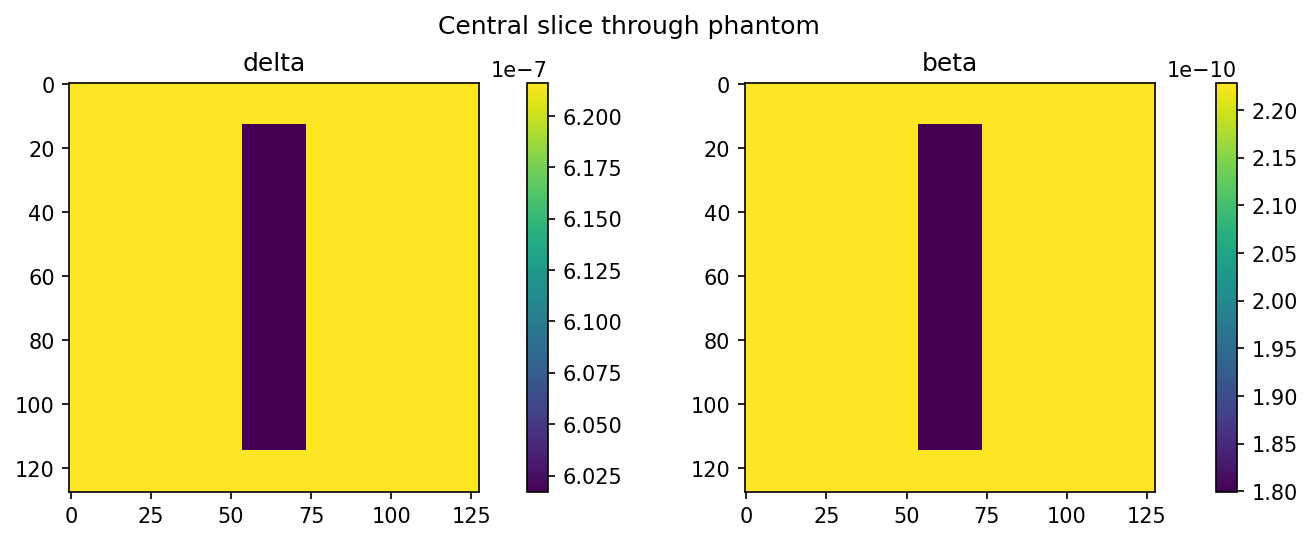

In [21]:
# First a peek at the phantom as a sanity check:

# Generate the phantom. 
obj_delta, obj_beta = make_fiber_phantom(N, Nz, dx, fiber_width, energy)

# Show.
fig, ax = plt.subplots(1, 2, figsize=[9,3.5], layout='constrained', dpi=150)
fig.suptitle('Central slice through phantom')
for i, obj in enumerate([obj_delta, obj_beta]):
    ax[i].set_title(['delta', 'beta'][i])
    m = ax[i].imshow(obj[obj.shape[0]//2,:,:])  
    fig.colorbar(m, ax=ax[i], pad=0)
plt.show()

In [22]:
# Tuple-ified Version. "Clean" because it is otherwise the same as original source code chromatix, intentionally.

def multislice_thick_sample_ALT_CLEAN(
    field: ScalarField,
    absorption_stack: Array,
    dn_stack: Array,
    n: float,
    thickness_per_slice: float,
    N_pad: int,
    propagator: Optional[Array] = None,
    kykx: Union[Array, Tuple[float, float]] = (0.0, 0.0),
    reverse_propagate_distance: Optional[float] = None,
) -> tuple[ScalarField, Array]:
    """
    Perturbs incoming ``ScalarField`` as if it went through a thick sample. The
    thick sample is modeled as being made of many thin slices each of a given
    thickness. The ``absorption_stack`` and ``dn_stack`` contain the absorbance
    and phase delay of each sample slice. Expects that the same sample is being
    applied to all elements across the batch of the incoming ``ScalarField``.

    A ``propagator`` defining the propagation kernel for the field through each
    slice can be provided. By default, a ``propagator`` is calculated inside
    the function. After passing through all slices, the field is propagated
    backwards to the center of the stack, or by the distances specified by
    ``reverse_propagate_distance`` if provided.

    Returns a tuple: a ``ScalarField`` with the result of the perturbation, and
    an array of maximum intensities at each iteration, for troubleshooting.
    

    Args:
        field: The complex field to be perturbed.
        absorption_stack: The sample absorption per micrometre for each slice
            defined as ``(D H W)`` array, where D is the total number of slices.
        dn_stack: sample refractive index change for each slice ``(D H W)`` array.
            Shape should be the same that for ``absorption_stack``.
        n: Average refractive index of the sample.
        thickness_per_slice: How far to propagate for each slice.
        N_pad: A keyword argument integer defining the pad length for the
            propagation FFT (NOTE: should not be a `jax` ``Array``, otherwise
            a ConcretizationError will arise when traced!). Use padding
            calculator utilities from ``chromatix.functional.propagation`` to
            calculate the padding.
        kykx: If provided, defines the orientation of the propagation. Should
            be an array of shape `(2,)` in the format ``[ky, kx]``.
        reverse_propagate_distance: If provided, propagates field at the end
            backwards by this amount from the top of the stack. By default,
            field is propagated backwards to the middle of the sample.
    """
    assert_equal_shape([absorption_stack, dn_stack])
    field = pad(field, N_pad)
    absorption_stack = center_pad(absorption_stack, (0, N_pad, N_pad))
    dn_stack = center_pad(dn_stack, (0, N_pad, N_pad))

    if propagator is None:
        propagator = compute_exact_propagator(field, thickness_per_slice, n, kykx)

    max_ints = []

    # NOTE(ac+dd): Unrolling this loop is much faster than ``jax.scan``-likes.
    for i, (absorption, dn) in enumerate(zip(absorption_stack, dn_stack)):
        absorption = _broadcast_2d_to_spatial(absorption, field.ndim)
        dn = _broadcast_2d_to_spatial(dn, field.ndim)
        field = cx.thin_sample(field, absorption, dn, thickness_per_slice)
        field = kernel_propagate(field, propagator)

        # troubleshooting:
        max_ints.append(field.intensity.max())

    # Propagate field backwards to the middle (or chosen distance) of the stack
    if reverse_propagate_distance is None:
        reverse_propagate_distance = thickness_per_slice * absorption_stack.shape[0] / 2

    # troubleshooting:
    old_field = field

    field = exact_propagate(
        field, z=-reverse_propagate_distance, n=n, kykx=kykx, N_pad=0
    )

    return (crop(field, N_pad), max_ints)

In [23]:
# Tuple-ified Hybrid Version - "gene splice" in transfer_propagate()

def multislice_thick_sample_ALT(
    field: ScalarField,
    absorption_stack: Array,
    dn_stack: Array,
    n: float,
    thickness_per_slice: float,
    N_pad: int,
    propagator: Optional[Array] = None,
    kykx: Union[Array, Tuple[float, float]] = (0.0, 0.0),
    reverse_propagate_distance: Optional[float] = None,
) -> tuple[ScalarField, Array]:
    """
    Perturbs incoming ``ScalarField`` as if it went through a thick sample. The
    thick sample is modeled as being made of many thin slices each of a given
    thickness. The ``absorption_stack`` and ``dn_stack`` contain the absorbance
    and phase delay of each sample slice. Expects that the same sample is being
    applied to all elements across the batch of the incoming ``ScalarField``.

    A ``propagator`` defining the propagation kernel for the field through each
    slice can be provided. By default, a ``propagator`` is calculated inside
    the function. After passing through all slices, the field is propagated
    backwards to the center of the stack, or by the distances specified by
    ``reverse_propagate_distance`` if provided.

    Returns a tuple: a ``ScalarField`` with the result of the perturbation, and
    an array of maximum intensities at each iteration, for troubleshooting.
    

    Args:
        field: The complex field to be perturbed.
        absorption_stack: The sample absorption per micrometre for each slice
            defined as ``(D H W)`` array, where D is the total number of slices.
        dn_stack: sample refractive index change for each slice ``(D H W)`` array.
            Shape should be the same that for ``absorption_stack``.
        n: Average refractive index of the sample.
        thickness_per_slice: How far to propagate for each slice.
        N_pad: A keyword argument integer defining the pad length for the
            propagation FFT (NOTE: should not be a `jax` ``Array``, otherwise
            a ConcretizationError will arise when traced!). Use padding
            calculator utilities from ``chromatix.functional.propagation`` to
            calculate the padding.
        kykx: If provided, defines the orientation of the propagation. Should
            be an array of shape `(2,)` in the format ``[ky, kx]``.
        reverse_propagate_distance: If provided, propagates field at the end
            backwards by this amount from the top of the stack. By default,
            field is propagated backwards to the middle of the sample.
    """
    assert_equal_shape([absorption_stack, dn_stack])
    field = pad(field, N_pad)
    absorption_stack = center_pad(absorption_stack, (0, N_pad, N_pad))
    dn_stack = center_pad(dn_stack, (0, N_pad, N_pad))

    if propagator is None:
        propagator = compute_exact_propagator(field, thickness_per_slice, n, kykx)

    max_ints = []

    # NOTE(ac+dd): Unrolling this loop is much faster than ``jax.scan``-likes.
    for i, (absorption, dn) in enumerate(zip(absorption_stack, dn_stack)):
        absorption = _broadcast_2d_to_spatial(absorption, field.ndim)
        dn = _broadcast_2d_to_spatial(dn, field.ndim)
        ####################### spliced, un-flipped ############################
        field = cx.thin_sample(field, absorption, dn, thickness_per_slice)
        # field = kernel_propagate(field, propagator)
        # instead: 
        cval = field.intensity.max()
        field = cx.transfer_propagate(field, thickness_per_slice, n, N_pad, cval=cval, mode='same')
        ########################################################################

        # troubleshooting:
        max_ints.append(field.intensity.max())

    # Propagate field backwards to the middle (or chosen distance) of the stack
    if reverse_propagate_distance is None:
        reverse_propagate_distance = thickness_per_slice * absorption_stack.shape[0] / 2

    # troubleshooting:
    old_field = field

    field = exact_propagate(
        field, z=-reverse_propagate_distance, n=n, kykx=kykx, N_pad=0
    )

    return (crop(field, N_pad), max_ints)

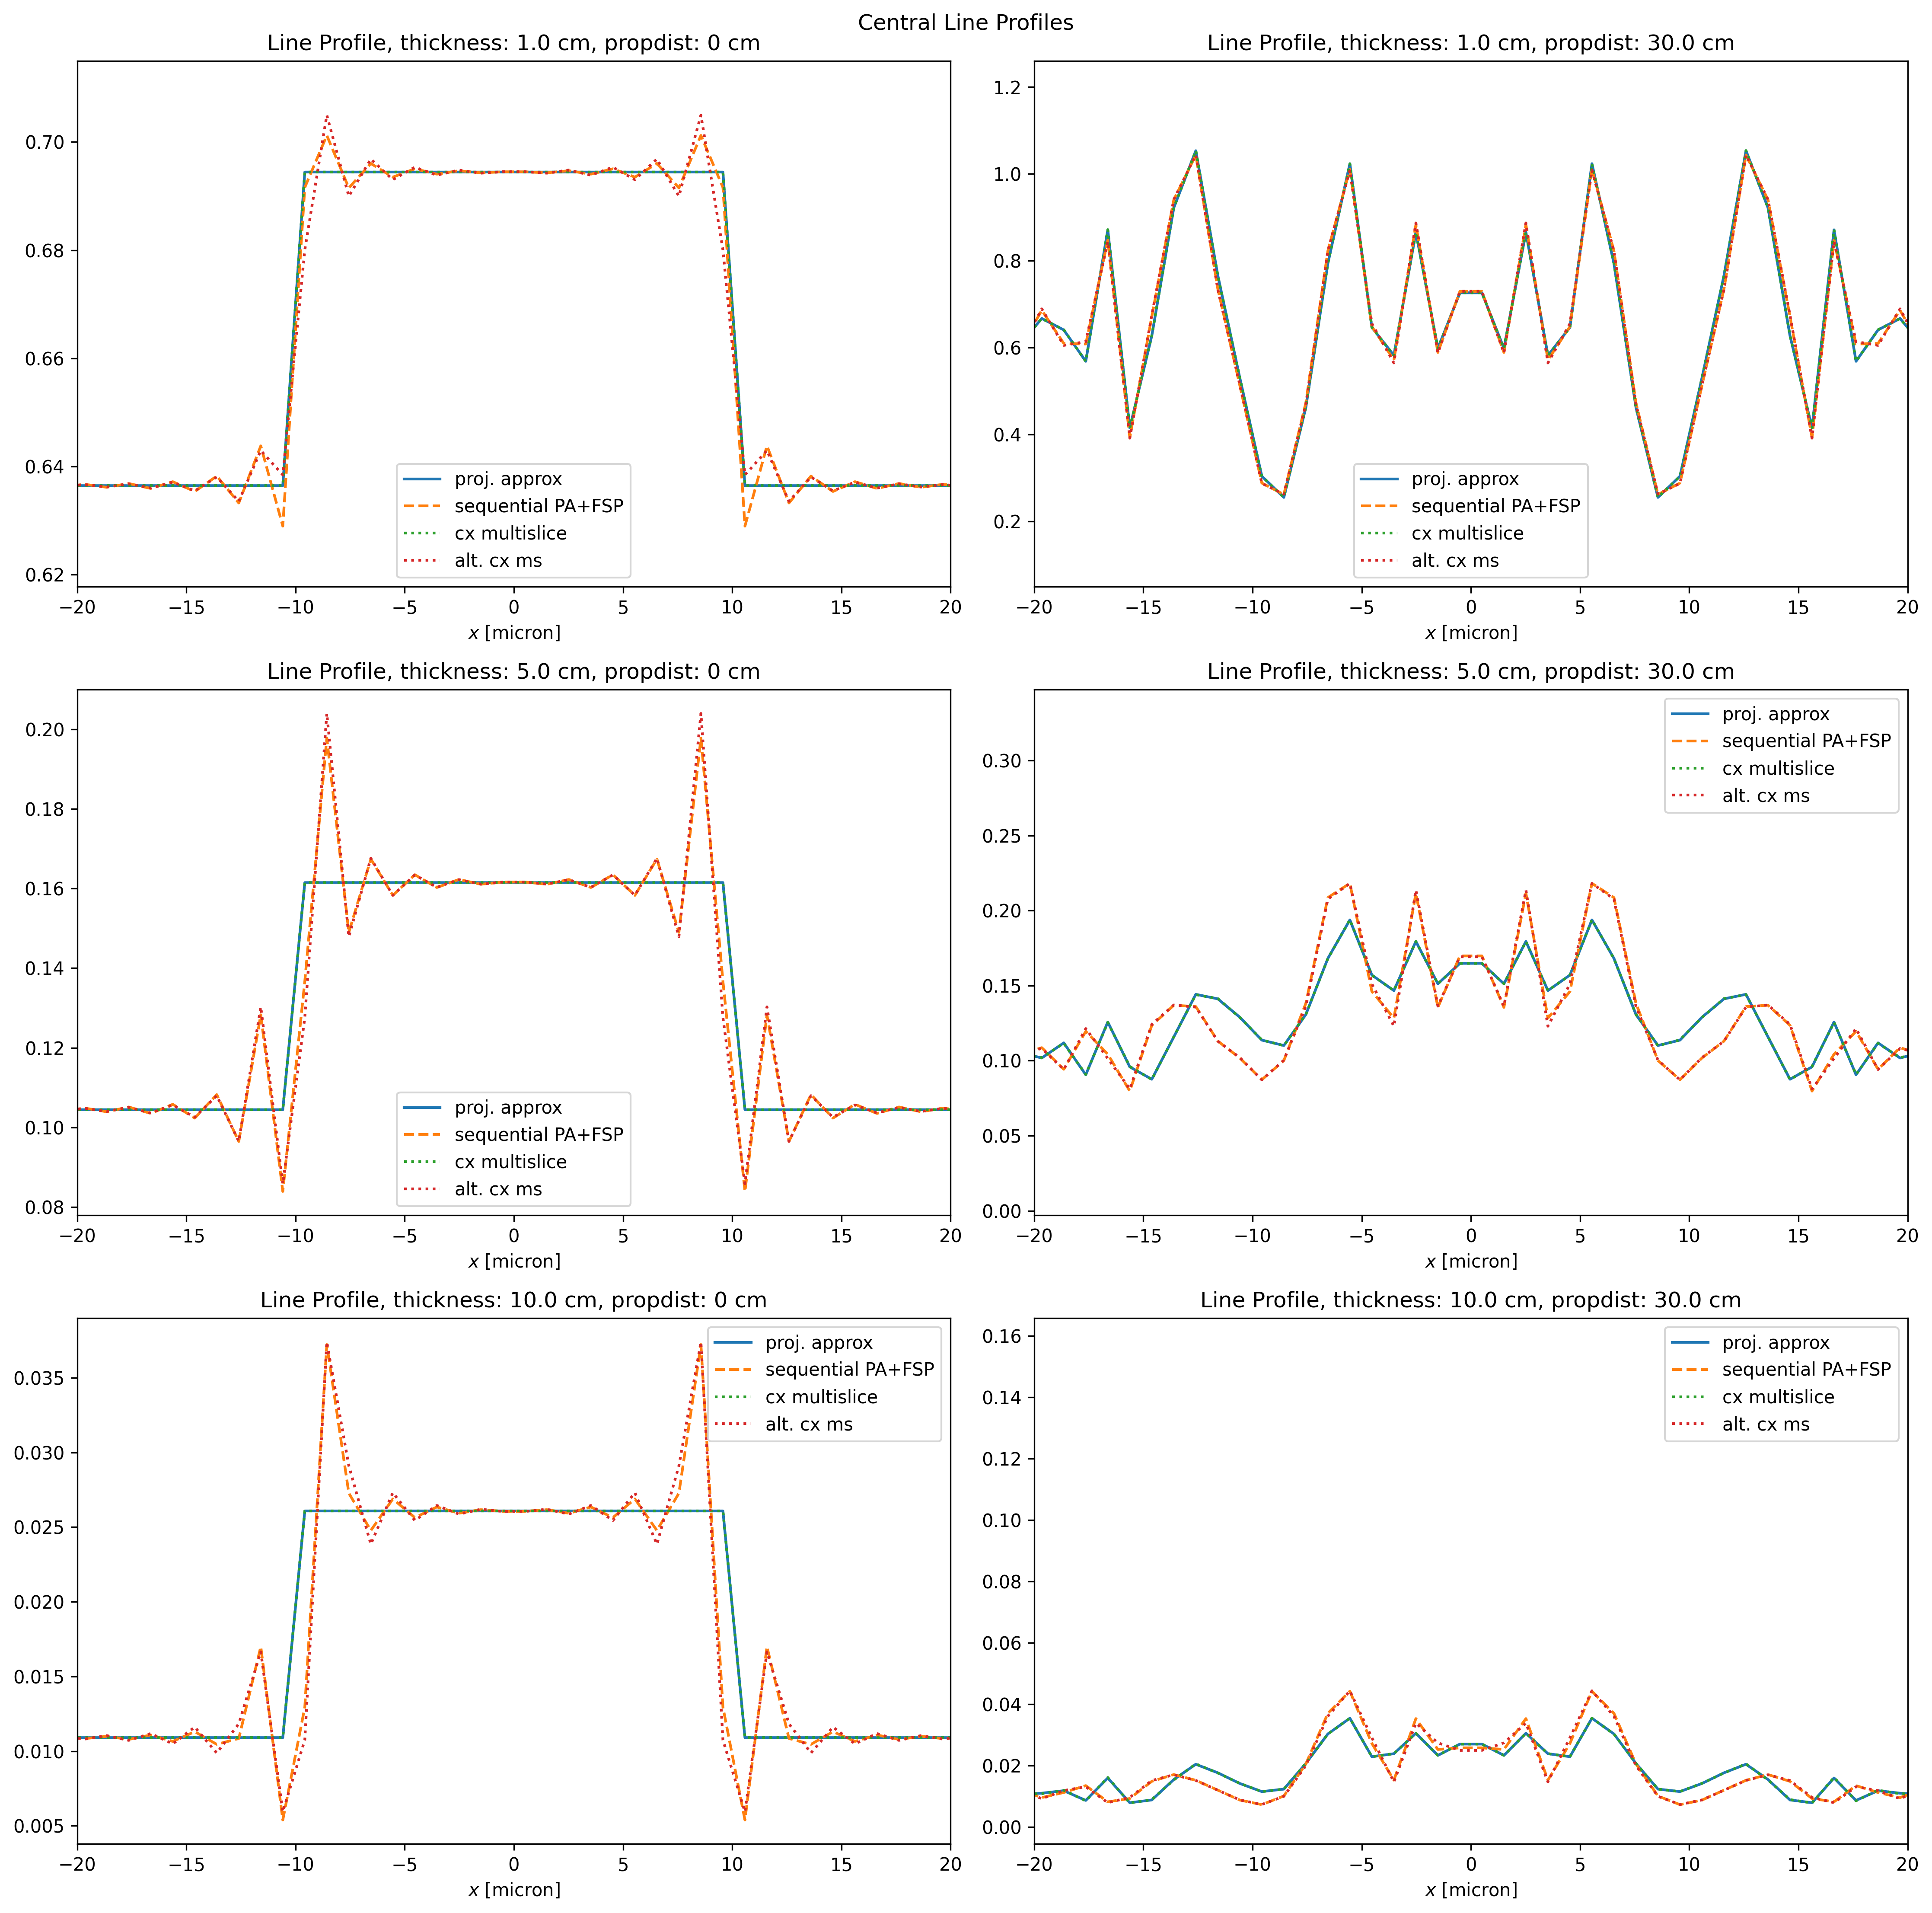

In [24]:
# Six simulations to demonstrate validity across thickness and propdist

method_2_max_ints_list = []
method_3_max_int_list = []
method_4_max_ints_list = []
method_5_max_ints_list = []

thickness_list = [1e-2, 5e-2, 10e-2]
propdist_list = [0, 30e-2]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=[15, 15], dpi=300)
fig.suptitle('Central Line Profiles')


for (i, thickness) in enumerate(thickness_list):
    for (j, propdist) in enumerate(propdist_list):
        
        dz = thickness/Nz

        # Generate the phantom
        obj_delta, obj_beta = make_fiber_phantom(N, Nz, dx, fiber_width, energy)


        #####
        # Incident field.
        field = cx.plane_wave(
            shape = phantom_shape[1:], 
            dx = dx,
            spectrum = get_wavelen(energy),
            spectral_density = 1.0,
        )
        field = (field / field.intensity.max()**0.5)
        cval = field.intensity.max()


        #####
        # Three (four) different methods for modulating the wave through the phantom:
        exit_fields = []

        # method 1: native chromatix function `multislice_thick_sample`
        exit_fields.append(
            cx.multislice_thick_sample(field, obj_beta, obj_delta, n_avg, dz, N_pad)   # maybe reverse_propagate_distance=0 
        )

        method_2_max_ints = []

        # method 2: sequentially repeating cx functions `thin_sample` and `transfer_propagate`
        # flipped, shows no difference 
        field_k = field      
        for k in range(Nz):
            field_k = cx.transfer_propagate(field_k, dz, n_medium, N_pad, cval=cval, mode='same')
            field_k = cx.thin_sample(field_k, obj_beta[k][None, ..., None, None], obj_delta[k][None, ..., None, None], dz)
            method_2_max_ints.append(field_k.intensity.max())
        exit_fields.append(field_k)

        method_2_max_ints_list.append(method_2_max_ints)

        # method 3: projection approximation `thin_sample` only.
        beta_proj = dz * jnp.sum(obj_beta, axis=0)
        delta_proj = dz * jnp.sum(obj_delta, axis=0)
        met_3_exit_field = cx.thin_sample(field, beta_proj[None, ..., None, None], delta_proj[None, ..., None, None], 1.0)
        method_3_max_int = met_3_exit_field.intensity.max()
        exit_fields.append(met_3_exit_field)
        method_3_max_int_list.append(method_3_max_int)

        # method 4: chromatix function `multislice_thick_sample` but I copied code instead of inheritance so I can mess with it
        # if reverse_propagate_distance is None: reverse_propagate_distance = thickness_per_slice * absorption_stack.shape[0] / 2
        met_4_exit_field, method_4_max_ints = multislice_thick_sample_ALT(field, obj_beta, obj_delta, n_avg, dz, N_pad, reverse_propagate_distance=None)
        exit_fields.append(met_4_exit_field)
        method_4_max_ints_list.append(method_4_max_ints)

        # "method 5": repeating a "clean" version of chromatix to get max intensities for the graph for comparison
        # intentionally should be the same as method 1
        met_5_exit_field, method_5_max_ints = multislice_thick_sample_ALT_CLEAN(field, obj_beta, obj_delta, n_avg, dz, N_pad, reverse_propagate_distance=None)
        method_5_max_ints_list.append(method_5_max_ints)

        #####
        # Apply the same *free-space* propagation method for each exit field:
        imgs = []
        for exit_field in exit_fields:
            det_field = cx.transfer_propagate(exit_field, propdist, n_medium, N_pad, cval=cval, mode='same')
            det_resample_func = init_plane_resample(det_shape, (det_dx, det_dx), resampling_method='linear')
            img = det_resample_func(det_field.intensity.squeeze()[...,None,None], field.dx.ravel()[:1])[...,0,0]
            img = img / (det_dx/dx)**2  # normalize counts to new pixel size
            imgs.append(img)


        #####
        # Extract the final images:
        img_ms_chromatix = imgs[0]   # chromatix multislice
        img_ms_seq = imgs[1]         # sequential multislice + propagation
        img_approx = imgs[2]         # projection approximation only
        img_ms_chr_alt = imgs[3]    # chromatix multislice but I can mess with it

        ax = axes[i, j]

        i_row = int((det_shape[0])/2)  
        x = 1e6 * np.linspace(-fov/2, fov/2, det_shape[0])
        ax.set_xlabel('$x$ [micron]')
        ax.set_xlim(-fiber_width*1e6, fiber_width*1e6)  # zoom into the fiber width
        # ax.set_ylim(0.00, 0.01)
        ax.plot(x, img_approx[i_row], linestyle='-', label='proj. approx') 
        ax.plot(x, img_ms_seq[i_row], linestyle='--', label='sequential PA+FSP')  
        ax.plot(x, img_ms_chromatix[i_row], linestyle=':', label='cx multislice')
        ax.plot(x, img_ms_chr_alt[i_row], linestyle=':', label='alt. cx ms')
        ax.legend()
        ax.set_title(f'Line Profile, thickness: {round(thickness*100, 2)} cm, propdist: {round(propdist*100, 2)} cm')


fig.tight_layout()
plt.show()

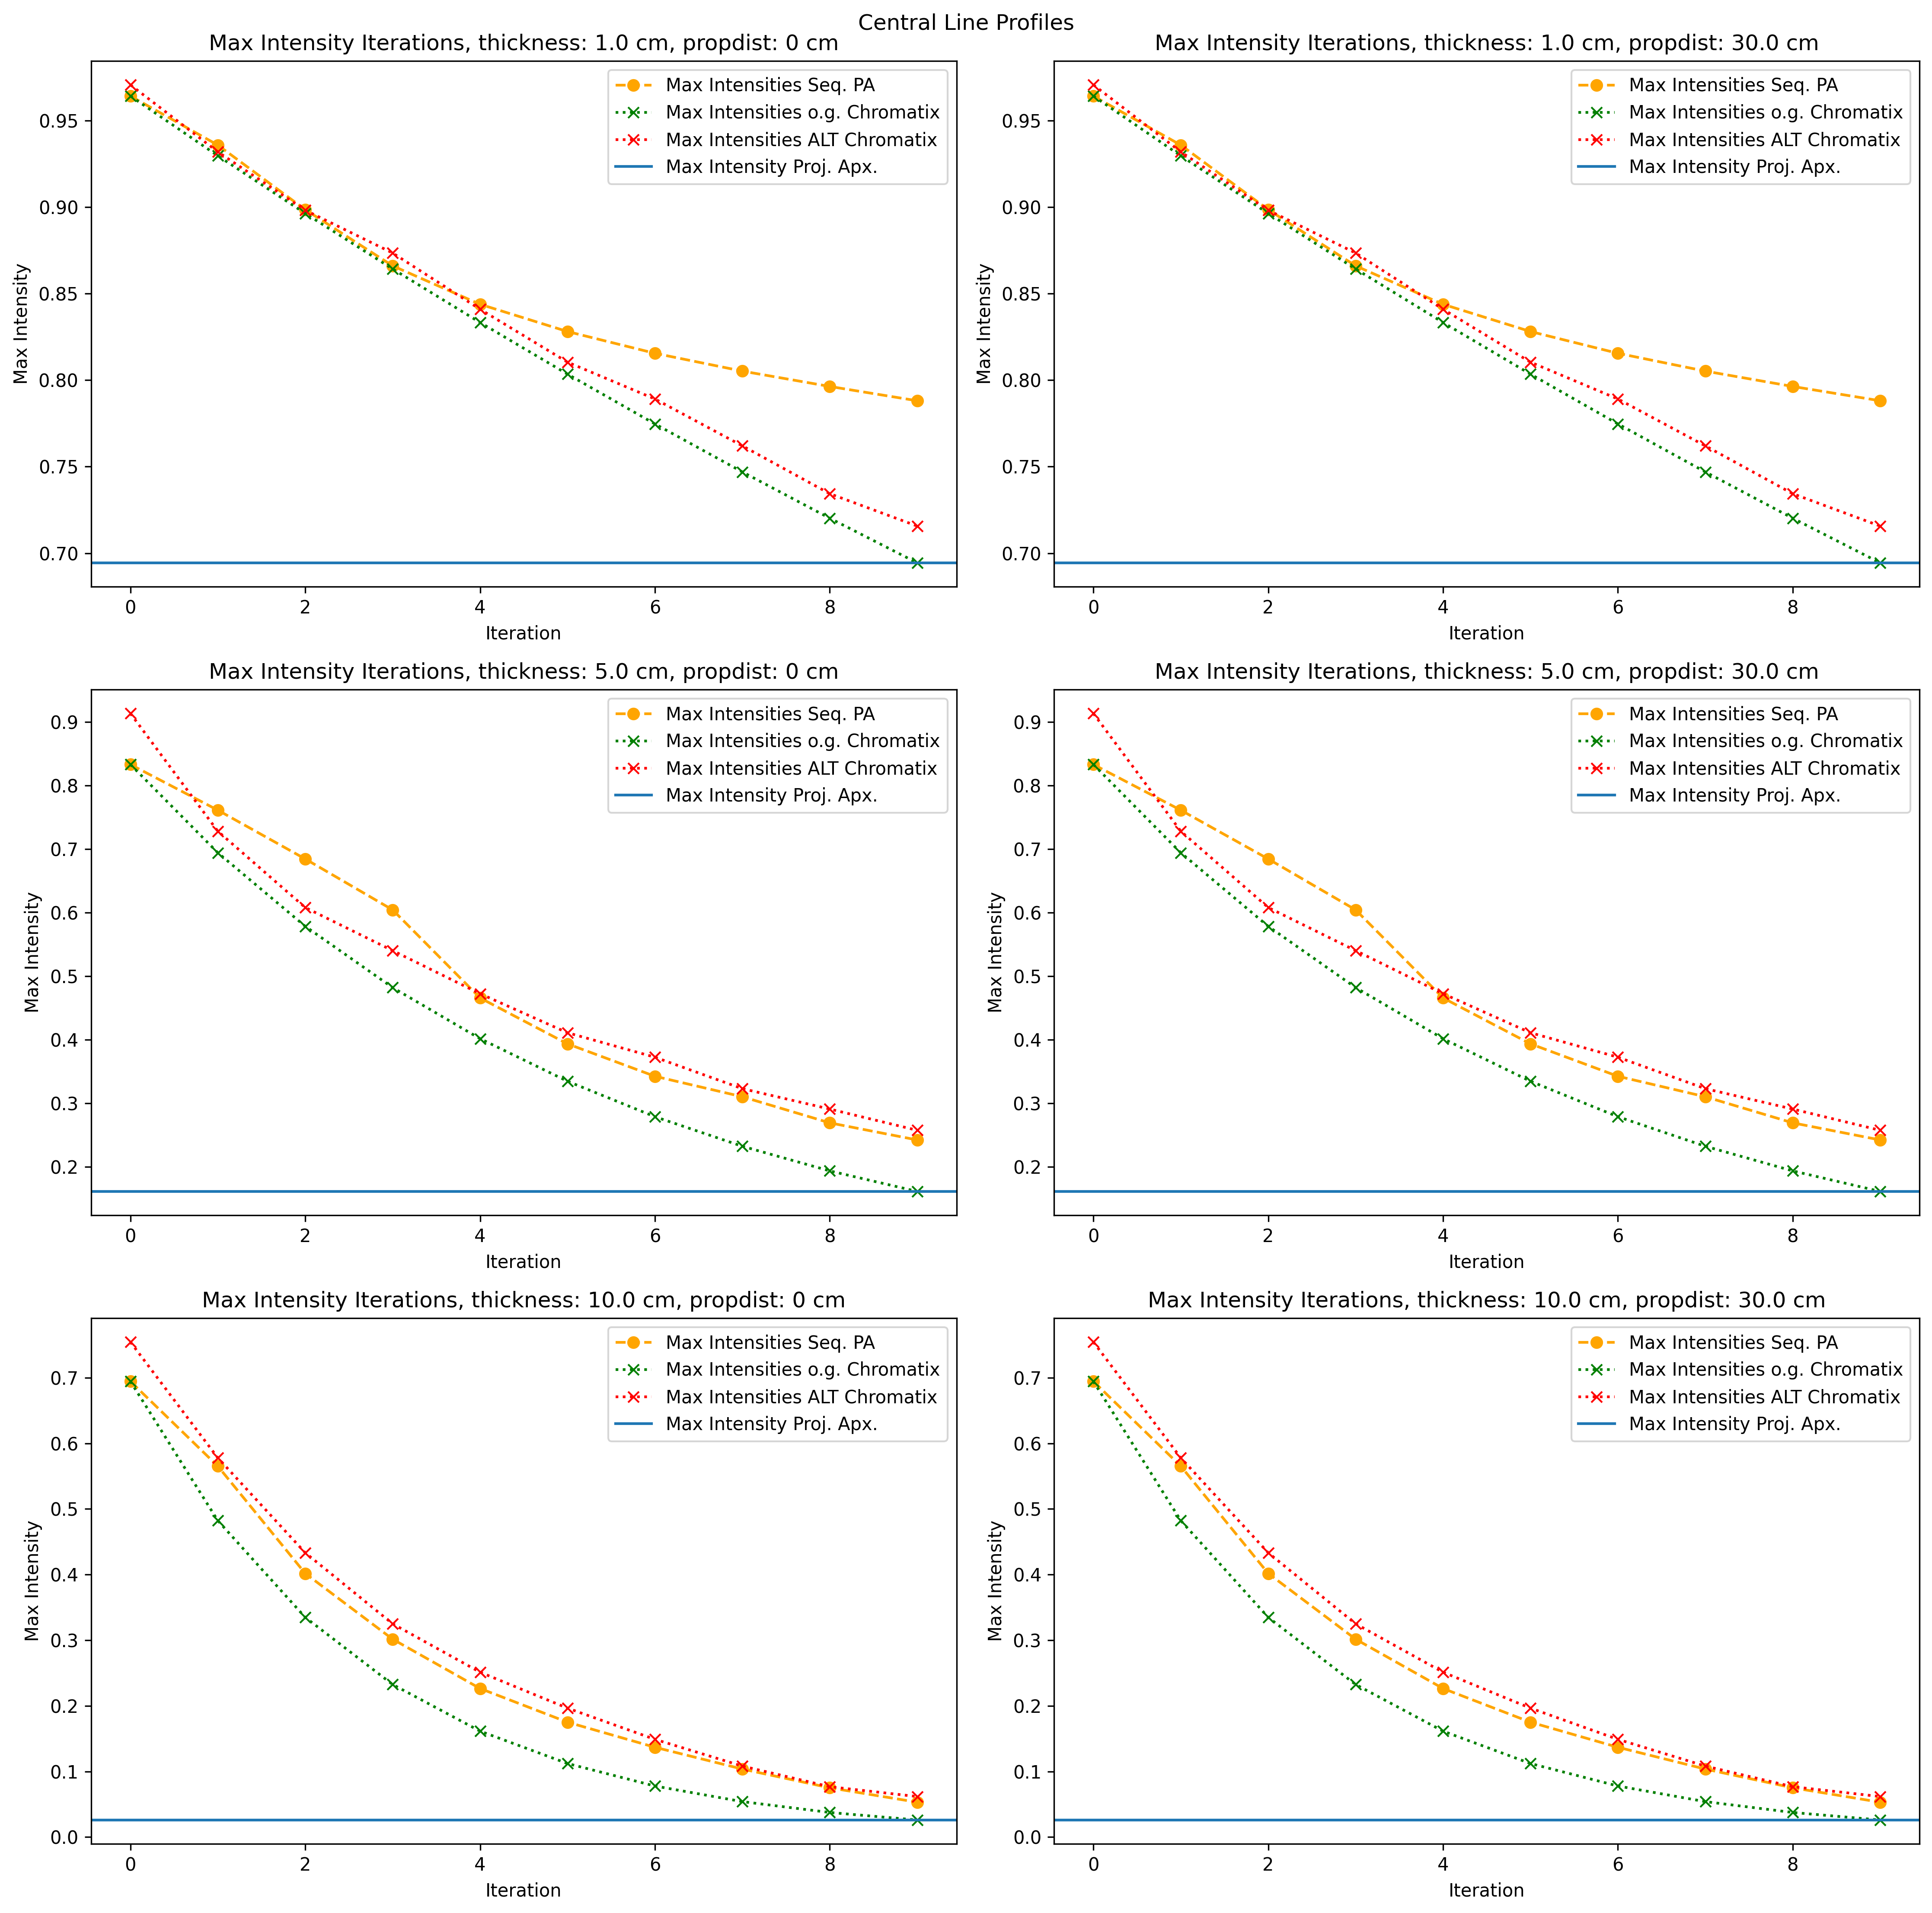

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=[15, 15], dpi=300)
fig.suptitle('Central Line Profiles')

list_idx = 0

for (i, thickness) in enumerate(thickness_list):
    for (j, propdist) in enumerate(propdist_list):

        ax = axes[i, j]

        assert(np.shape(method_2_max_ints_list[list_idx]) == np.shape(method_4_max_ints_list[list_idx]))
        assert(np.shape(method_2_max_ints_list[list_idx]) == np.shape(method_5_max_ints_list[list_idx]))
        indices = np.arange(len(method_2_max_ints_list[list_idx]))

        ax.plot(indices, method_2_max_ints_list[list_idx], linestyle='--', marker='o', label='Max Intensities Seq. PA', color='orange')
        ax.plot(indices, method_5_max_ints_list[list_idx], linestyle=':', marker='x', label='Max Intensities o.g. Chromatix', color='g')
        ax.plot(indices, method_4_max_ints_list[list_idx], linestyle=':', marker='x', label='Max Intensities ALT Chromatix', color='r')
        ax.axhline(y=method_3_max_int_list[list_idx], color='C0', linestyle='-', label=f'Max Intensity Proj. Apx.')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Max Intensity')
        ax.legend()
        ax.set_title(f'Max Intensity Iterations, thickness: {round(thickness*100, 2)} cm, propdist: {round(propdist*100, 2)} cm')

        list_idx = list_idx + 1


fig.tight_layout()
plt.show()

## Using Imported Chromatix

goal: use the known-good, known-jit-able native Chromatix version, just ask it to use transfer_propagate().

replaced _ALT_CLEAN() with the native import. replaced _ALT() with native import plus "propagator" argument passed in.

iteration curves won't be possible of course because the native version is not tuple-ified. 

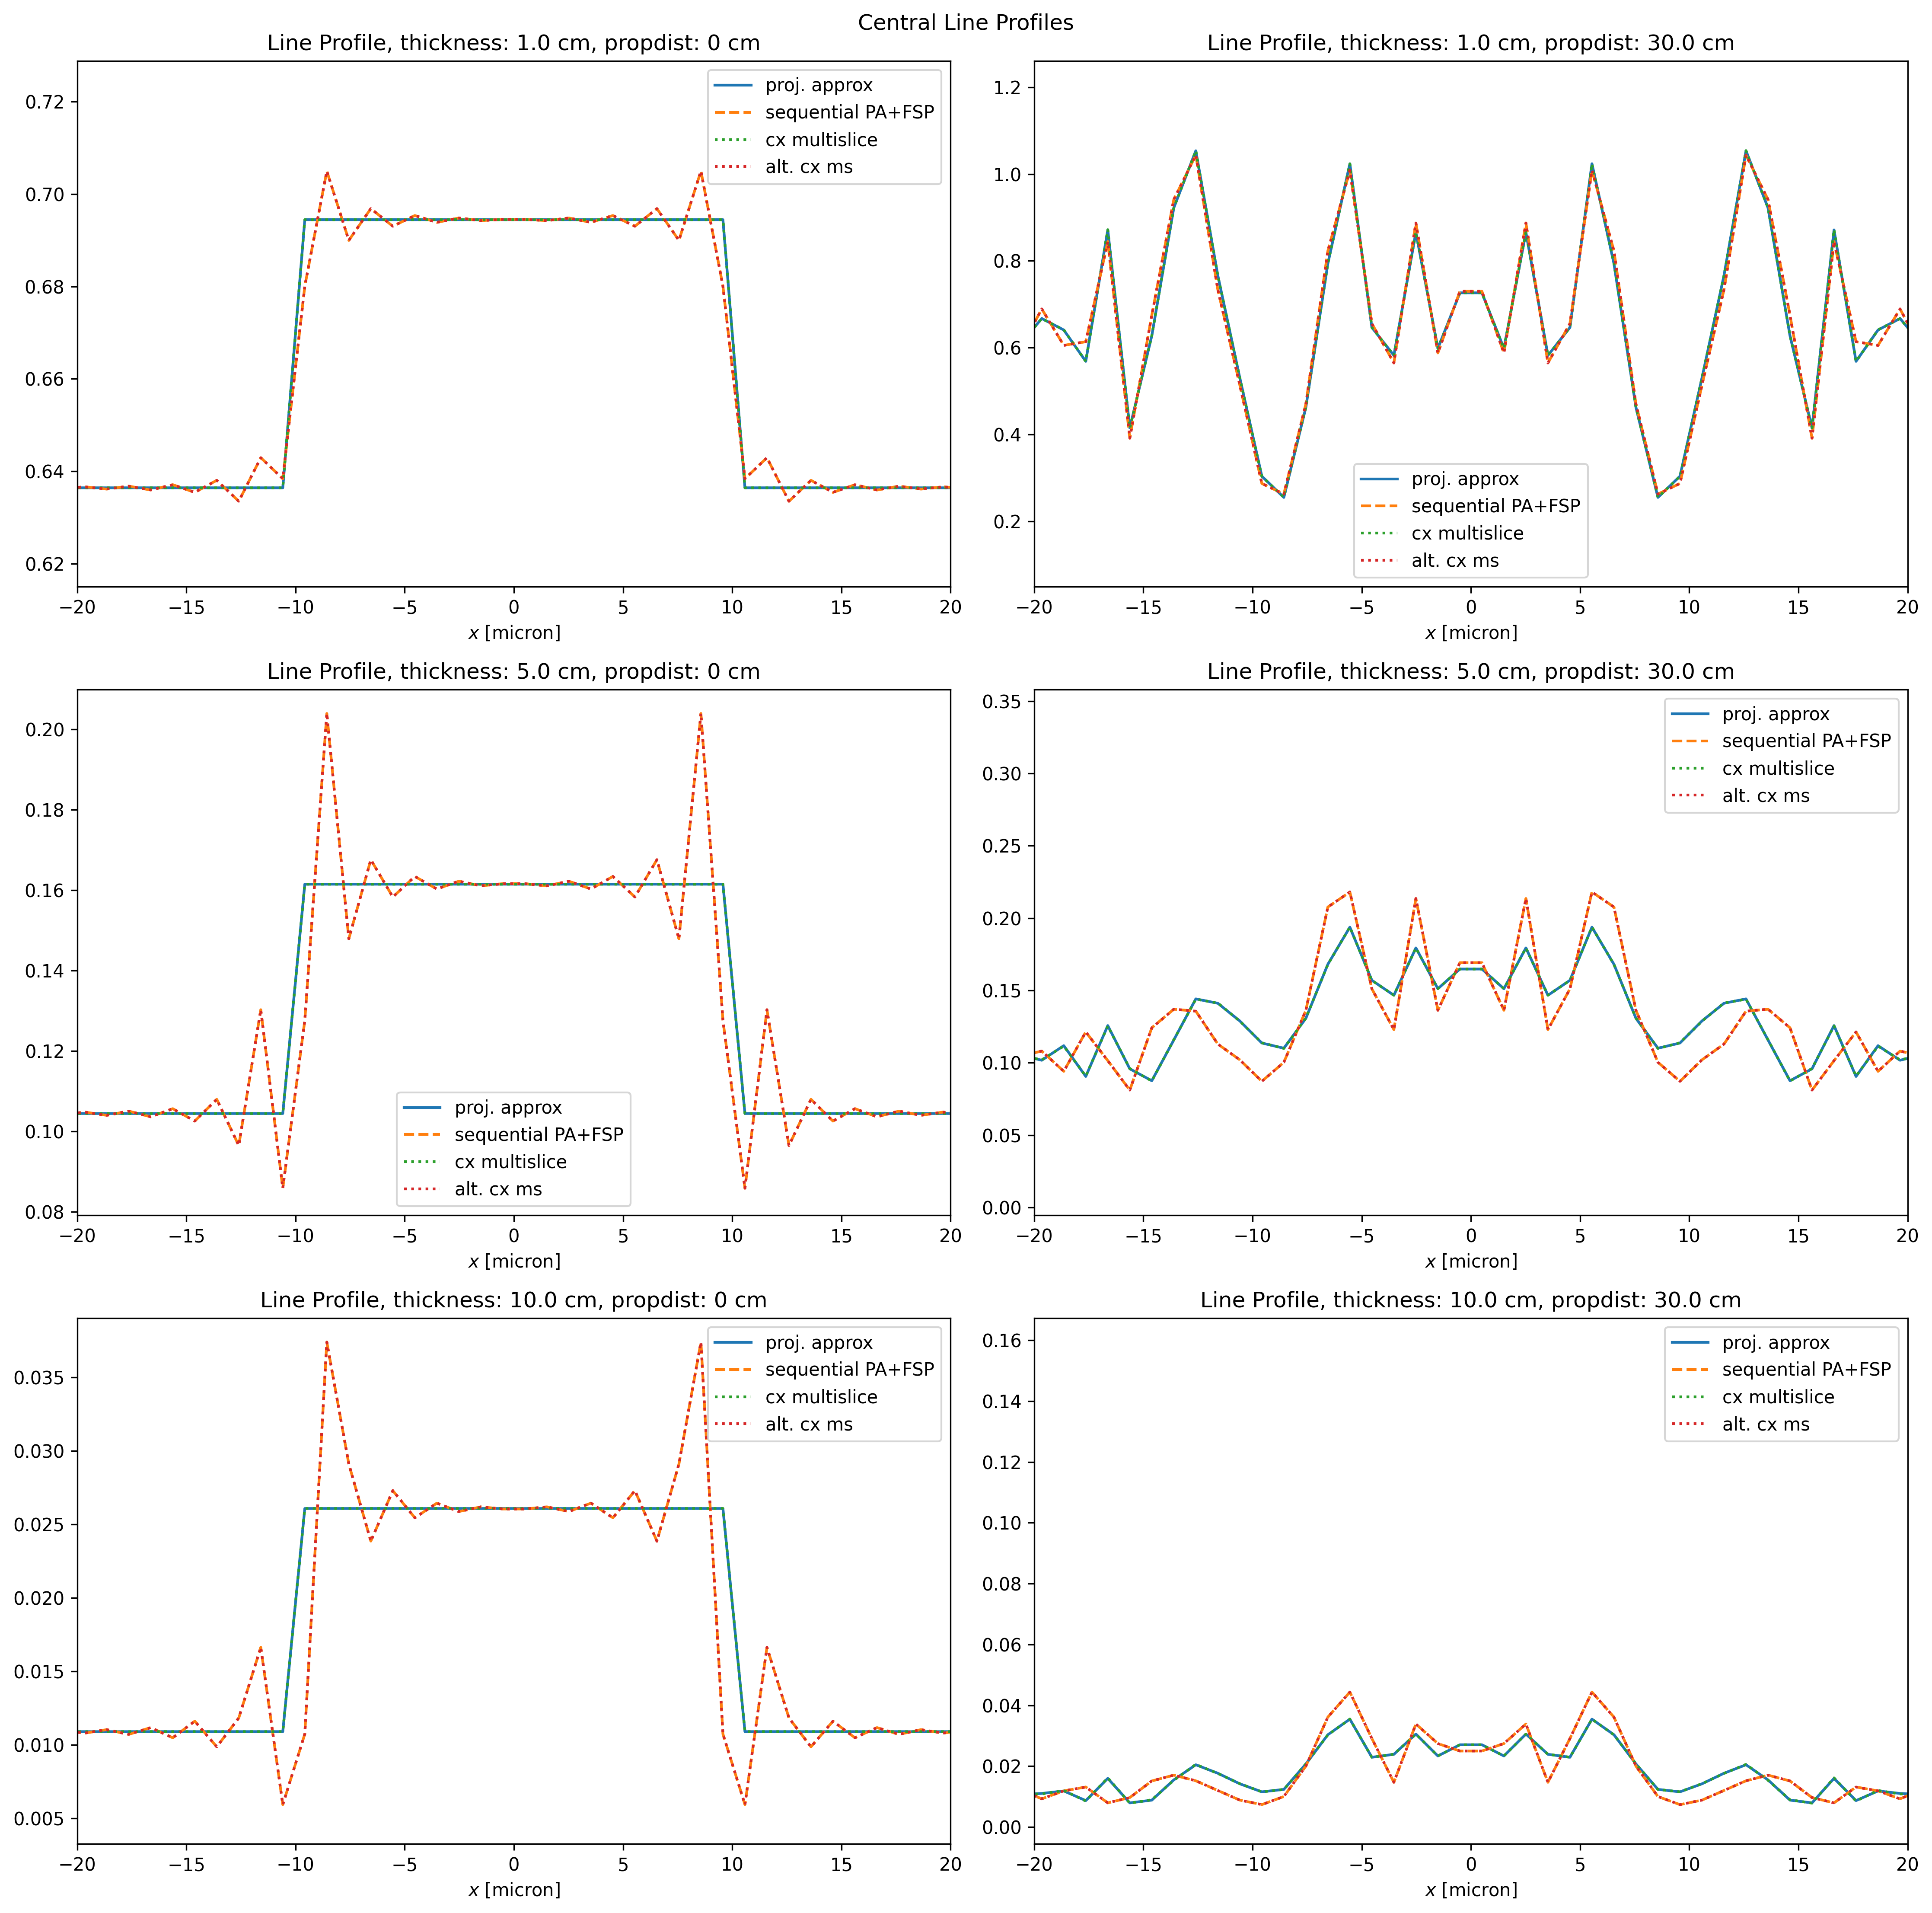

In [29]:
# Six simulations to demonstrate validity across thickness and propdist

thickness_list = [1e-2, 5e-2, 10e-2]
propdist_list = [0, 30e-2]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=[15, 15], dpi=300)
fig.suptitle('Central Line Profiles')


for (i, thickness) in enumerate(thickness_list):
    for (j, propdist) in enumerate(propdist_list):
        
        dz = thickness/Nz

        # Generate the phantom
        obj_delta, obj_beta = make_fiber_phantom(N, Nz, dx, fiber_width, energy)


        #####
        # Incident field.
        field = cx.plane_wave(
            shape = phantom_shape[1:], 
            dx = dx,
            spectrum = get_wavelen(energy),
            spectral_density = 1.0,
        )
        field = (field / field.intensity.max()**0.5)
        cval = field.intensity.max()


        #####
        # Three (four) different methods for modulating the wave through the phantom:
        exit_fields = []

        # method 1: native chromatix function `multislice_thick_sample`
        exit_fields.append(
            cx.multislice_thick_sample(field, obj_beta, obj_delta, n_avg, dz, N_pad) 
        )

        # method 2: sequentially repeating cx functions `thin_sample` and `transfer_propagate`
        field_k = field      
        for k in range(Nz):
            field_k = cx.thin_sample(field_k, obj_beta[k][None, ..., None, None], obj_delta[k][None, ..., None, None], dz)
            field_k = cx.transfer_propagate(field_k, dz, n_medium, N_pad, cval=cval, mode='same')
            method_2_max_ints.append(field_k.intensity.max())
        exit_fields.append(field_k)

        # method 3: projection approximation `thin_sample` only.
        beta_proj = dz * jnp.sum(obj_beta, axis=0)
        delta_proj = dz * jnp.sum(obj_delta, axis=0)
        met_3_exit_field = cx.thin_sample(field, beta_proj[None, ..., None, None], delta_proj[None, ..., None, None], 1.0)
        exit_fields.append(met_3_exit_field)

        # method 4: native chromatix ms with additional argument to make it use transfer_propagate()
        propagator_transfer = cx.compute_transfer_propagator(pad(field, N_pad, cval=cval), dz, n_medium)
        met_4_exit_field = cx.multislice_thick_sample(field, obj_beta, obj_delta, n_avg, dz, N_pad, 
                                                      propagator=propagator_transfer, reverse_propagate_distance=None)
        exit_fields.append(met_4_exit_field)

        #####
        # Apply the same *free-space* propagation method for each exit field:
        imgs = []
        for exit_field in exit_fields:
            det_field = cx.transfer_propagate(exit_field, propdist, n_medium, N_pad, cval=cval, mode='same')
            det_resample_func = init_plane_resample(det_shape, (det_dx, det_dx), resampling_method='linear')
            img = det_resample_func(det_field.intensity.squeeze()[...,None,None], field.dx.ravel()[:1])[...,0,0]
            img = img / (det_dx/dx)**2  # normalize counts to new pixel size
            imgs.append(img)


        #####
        # Extract the final images:
        img_ms_chromatix = imgs[0]   # chromatix multislice
        img_ms_seq = imgs[1]         # sequential multislice + propagation
        img_approx = imgs[2]         # projection approximation only
        img_ms_chr_alt = imgs[3]    # chromatix multislice but I can mess with it

        ax = axes[i, j]

        i_row = int((det_shape[0])/2)  
        x = 1e6 * np.linspace(-fov/2, fov/2, det_shape[0])
        ax.set_xlabel('$x$ [micron]')
        ax.set_xlim(-fiber_width*1e6, fiber_width*1e6)  # zoom into the fiber width
        # ax.set_ylim(0.00, 0.01)
        ax.plot(x, img_approx[i_row], linestyle='-', label='proj. approx') 
        ax.plot(x, img_ms_seq[i_row], linestyle='--', label='sequential PA+FSP')  
        ax.plot(x, img_ms_chromatix[i_row], linestyle=':', label='cx multislice')
        ax.plot(x, img_ms_chr_alt[i_row], linestyle=':', label='alt. cx ms')
        ax.legend()
        ax.set_title(f'Line Profile, thickness: {round(thickness*100, 2)} cm, propdist: {round(propdist*100, 2)} cm')


fig.tight_layout()
plt.show()